# Deep Reinforcement Learning Laboratory

In this laboratory session we will work on getting more advanced versions of Deep Reinforcement Learning algorithms up and running. Deep Reinforcement Learning is **hard**, and getting agents to stably train can be frustrating and requires quite a bit of subtlety in analysis of intermediate results. We will start by refactoring (a bit) my implementation of `REINFORCE` on the [Cartpole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/). 

## Exercise 1: Improving my `REINFORCE` Implementation (warm up)

In this exercise we will refactor a bit and improve some aspects of my `REINFORCE` implementation. 

**First Things First**: Spend some time playing with the environment to make sure you understand how it works.

In [1]:
## Helper function to inspect quickly the object by printing the methods
def class_methods(obj):
    methods = []
    for name in dir(obj):
        try:
            attr = getattr(obj, name)
            if callable(attr) and not name.startswith("__"):
                methods.append(name)
        except Exception:
            pass
    return methods


def print_obj_summary(obj,str = "obj"):
    print(f"\n Info about ",str," -> \n",
        "Class : ", obj,"\n",
        "Obj_attributess : ", vars(obj),"\n"
        "Relevant methods : ",class_methods(obj),"\n")
    


In [2]:
import gymnasium as gym

# Instantiate a rendering and a non-rendering environment.
env_render = gym.make('CartPole-v1', render_mode = 'human')
env = gym.make('CartPole-v1',render_mode = None)
env_render = gym.make('CartPole-v1')
observation , info = env.reset()
print(f"Example of obseravation : ", observation ,"\n Info :",info)
## Observation is a ndarray


print_obj_summary(env,"env")
print_obj_summary(env.action_space,"action space") ## we can move 2 directions
print_obj_summary(env.observation_space,"observation space") ## Observation space is a Discrete(2)

## Trying to sample from both spaces
print(f"sample from observation space ",env.observation_space.sample())
print(f"sample from action space ",env.action_space.sample())

## Trying to perform a step , ( Already called .reset() )
action = env.action_space.sample()
observation , reward , truncated , terminated , info  = env.step(action)
print(reward)

## Finally simulationg one episode

terminated = False
env.reset()
step = 0
while not (terminated or truncated):
    action = env.action_space.sample()
    observation , reward , truncated , terminated , info  = env.step(action)
    step += 1
    print(f"Reward at step ",step,": ",reward)
    print(f"Info at step ",step,": ",info)
print("episode lasted for ",step," steps")

Example of obseravation :  [ 0.04666042 -0.00240007 -0.00220702 -0.01080975] 
 Info : {}

 Info about  env  -> 
 Class :  <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>> 
 Obj_attributess :  {'_saved_kwargs': {'max_episode_steps': 500}, 'env': <OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>, '_action_space': None, '_observation_space': None, '_metadata': None, '_cached_spec': EnvSpec(id='CartPole-v1', entry_point='gymnasium.envs.classic_control.cartpole:CartPoleEnv', reward_threshold=475.0, nondeterministic=False, max_episode_steps=500, order_enforce=True, disable_env_checker=False, kwargs={'render_mode': None}, namespace=None, name='CartPole', version=1, additional_wrappers=(), vector_entry_point='gymnasium.envs.classic_control.cartpole:CartPoleVectorEnv'), '_max_episode_steps': 500, '_elapsed_steps': 0} 
Relevant methods :  ['class_name', 'close', 'get_wrapper_attr', 'has_wrapper_attr', 'render', 'reset', 'set_wrapper_attr', 'step', 'wrapper_spe

**Next Things Next**: Now get your `REINFORCE` implementation working on the environment. You can import my (probably buggy and definitely inefficient) implementation here. Or even better, refactor an implementation into a separate package from which you can `import` the stuff you need here. 

In [3]:
# Your code here. You should be able to train an agent to solve Cartpole. This will be our starting point.
import numpy as np
from src.train import train

/home/andrea/dev/DLA/3_DRL/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Currently available device:  cuda


**Last Things Last**: My implementation does a **super crappy** job of evaluating the agent performance during training. The running average is not a very good metric. Modify my implementation so that every $N$ iterations (make $N$ an argument to the training function) the agent is run for $M$ episodes in the environment. Collect and return: (1) The average **total** reward received over the $M$ iterations; and (2) the average episode length. Analyze the performance of your agents with these new metrics.

**First** we define the seed , the CartPole env. and where we want to save the weights of our policy net

In [4]:
## args

seed = 1234
env_string = "CartPole-v1"
w_path = "weights" 

We run our **traing loop** and collect the result including the metrics requested.

In [ ]:
# Your code here
running_rewards,eval_rewards,eval_lenghts = train(
        seed = seed,
        env_string = env_string,
        record_final_video = True,
        w_path = w_path
        )


Now we plot our results

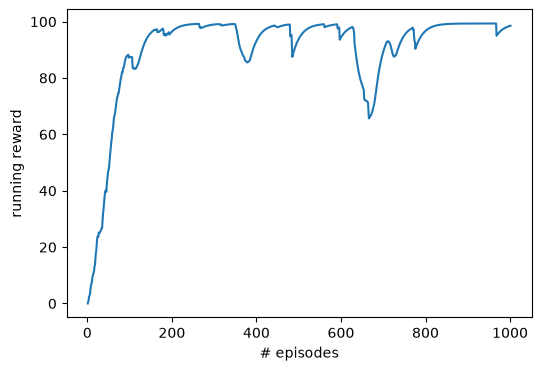

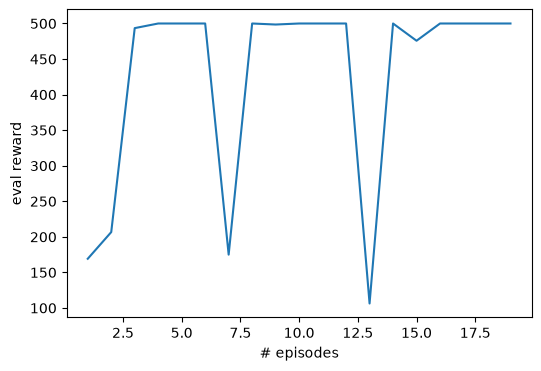

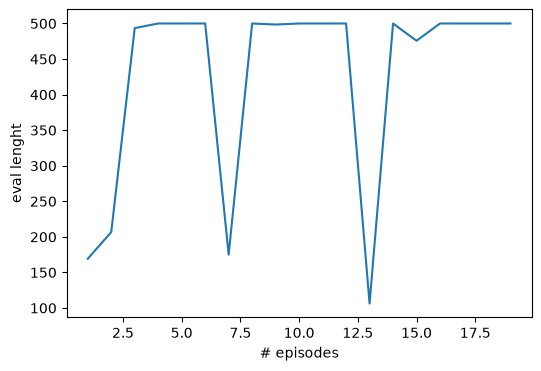

In [5]:
%matplotlib inline
from src.plot import plot_results

running_rewards = np.load("numeric/running_rewards.npy")
eval_rewards = np.load("numeric/eval_rewards.npy")
eval_lenghts = np.load("numeric/eval_lenght.npy")

plot_results(
        (np.arange(1,len(running_rewards)+1) , running_rewards , "# episodes" , "running reward"),
        (np.arange(1,len(eval_rewards)+1) , eval_rewards , "# episodes" , "eval reward"),
        (np.arange(1,len(eval_lenghts)+1) , eval_lenghts , "# episodes" , "eval lenght"),
        show = True,
        save = False
    )

-----
## Exercise 2: `REINFORCE` with a Value Baseline (warm up)

In this exercise we will augment my implementation (or your own) of `REINFORCE` to subtract a baseline from the target in the update equation in order to stabilize (and hopefully speed-up) convergence. For now we will stick to the Cartpole environment.



**First Things First**: Recall from the slides on Deep Reinforcement Learning that we can **subtract** any function that doesn't depend on the current action from the q-value without changing the (maximum of our) objecttive function $J$:  

$$ \nabla J(\boldsymbol{\theta}) \propto \sum_{s} \mu(s) \sum_a \left( q_{\pi}(s, a) - b(s) \right) \nabla \pi(a \mid s, \boldsymbol{\theta}) $$

In `REINFORCE` this means we can subtract from our target $G_t$:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - b(S_t)) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

Since we are only interested in the **maximum** of our objective, we can also **rescale** our target by any function that also doesn't depend on the action. A **simple baseline** which is even independent of the state -- that is, it is **constant** for each episode -- is to just **standardize rewards within the episode**. So, we **subtract** the average return and **divide** by the variance of returns:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha \left(\frac{G_t - \bar{G}}{\sigma_G}\right) \nabla  \pi(A_t \mid s, \boldsymbol{\theta}) $$

This baseline is **already** implemented in my implementation of `REINFORCE`. Experiment with and without this standardization baseline and compare the performance. We are going to do something more interesting.

In [ ]:
# Your code here. Modify your implementation of `REINFORCE` to optionally use the standardize baseline.

**The Real Exercise**: Standard practice is to use the state-value function $v(s)$ as a baseline. This is intuitively appealing -- we are more interested in updating out policy for returns that estimate the current **value** worse. Our new update becomes:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - \tilde{v}(S_t \mid \mathbf{w})) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

where $\tilde{v}(s \mid \mathbf{w})$ is a **deep neural network** with parameters $w$ that estimates $v_\pi(s)$. What neural network? Typically, we use the **same** network architecture as that of the Policy.

**Your Task**: Modify your implementation to fit a second, baseline network to estimate the value function and use it as **baseline**. 

In [ ]:
# Your code here.


-----

## Exercise 3: Going Deeper

As usual, pick **AT LEAST ONE** of the following exercises to complete.

### Exercise 3.1: Solving Cartpole and Lunar Lander with A2C (easy)

Implement the Advantage Actor-Critic (A2C) algorithm and use it to solve both `Cartpole` (to validate your implementation) and the [Lunar Lander Environment](https://gymnasium.farama.org/environments/box2d/lunar_lander/). This environment is a little bit harder than Cartpole, but not much. Make sure you perform the appropriate types of analyses to quantify and qualify the performance of your agents.

**Why choose this exercise?** A2C is a good, "pure" TD-based reinforcement learning algorithm and is the basis for more advanced Policy Gradient approaches. Having a good understanding of it is a good starting point for diving into the state-of-the-art in on-policy Deep Reinforcement Learning.


### Exercise 3.2: Solving Cartpole and Lunar Lander with `Deep Q-Learning` (harder)

On policy Deep Reinforcement Learning tends to be **very unstable**. Write an implementation (or adapt an existing one) of `Deep Q-Learning` to solve these two environments (Cartpole and Lunar Lander). To do this you will need to implement a **Replay Buffer** and use a second, slow-moving **target Q-Network** to stabilize learning.

**Why choose this exercise?** DQL, similarly to A2C, provides a good starting point for diving into the state-of-the-art in *off-policy* Deep Reinforcement Learning algorithms.

### Exercise 3.3: Solving the OpenAI CarRacing environment (hardest) 

Use `Deep Q-Learning` -- or even better, an off-the-shelf implementation of **Proximal Policy Optimization (PPO)** -- to train an agent to solve the [OpenAI CarRacing](https://github.com/andywu0913/OpenAI-GYM-CarRacing-DQN) environment. This will be the most *fun*, but also the most *difficult*. Some tips:

1. Make sure you use the `continuous=False` argument to the environment constructor. This ensures that the action space is **discrete** (we haven't seen how to work with continuous action spaces).
2. Your Q-Network will need to be a CNN. A simple one should do, with two convolutional + maxpool layers, folowed by a two dense layers. You will **definitely** want to use a GPU to train your agents.
3. The observation space of the environment is a single **color image** (a single frame of the game). Most implementations stack multiple frames (e.g. 3) after converting them to grayscale images as an observation.

**Why choose this exercise?** This exercise is a good simulation of a *real* Deep Reinforcement Learning problem that involves both *perception* and *action* -- just like the problems you might find in the wild. It will require you to think carefully about monitoring performance during training and carefully adapting hyperparameters to learn a good policy for this environment.


### Exercise 3.4: Instruction Fine-tuning an LLM (very hard)

In this exercise you will adapt a small LLM (e.g. `Qwen/Qwen3-0.6B-Base`) on one or more procedural reasoning tasks from the [Reasoning Gym](https://github.com/open-thought/reasoning-gym/tree/main). Adapting LLMs with Reinforcement Learning, however, requires a **ton** of infrastructural code for wrangling data, managing replay buffers, and coordinating batch construction and masking. Thus, it was not possible to come up with a reasonably-dimensioned exercise that can be done *from scratch* like the ones above.

However, for this exercise, you can use the [RLHF Book](https://github.com/natolambert/rlhf-book/tree/main) by Nathan Lambert as a basis for your experimentation. The book contains a wealth of information and -- most importantly -- *code* for implementing RLHF pipelines.

**The Exercise**: Pick an (easy) dataset from the Reasoning Gym, and adapt Qwen to solve it. Anything goes. This is an experimental exercise for this year, so learn something and *have fun*.

**Important**: Just copying the RLHF Book repository and running the code is, obviously, not an acceptable solution for this exercise. I expect you to *reuse* the code from the repository and do something (minimally) different than what is already in the repository. And, as always, whatever you submit, you must be able to explain *everything* it doe.
 